In [1]:
from pathlib import Path
import os, random, shutil, time

BASE = Path("/scratch/project_2001220") / os.environ["USER"] / "cv_lecture2"
RAW_IMG_DIR = BASE / "raw" / "data" / "dogs-vs-cats" / "train" / "train"
OUT = BASE / "imagefolder"

t0 = time.time()
assert RAW_IMG_DIR.exists(), f"Missing: {RAW_IMG_DIR}"

if OUT.exists():
    shutil.rmtree(OUT)

for split in ["train", "val"]:
    for cls in ["cat", "dog"]:
        (OUT / split / cls).mkdir(parents=True, exist_ok=True)

cats = sorted(RAW_IMG_DIR.glob("cat.*.jpg"))
dogs = sorted(RAW_IMG_DIR.glob("dog.*.jpg"))
print("Found:", len(cats), "cats,", len(dogs), "dogs")

random.seed(42)
random.shuffle(cats)
random.shuffle(dogs)

def safe_link(src, dst):
    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def split_place(paths, cls):
    n = len(paths)
    n_train = int(0.8 * n)
    for p in paths[:n_train]:
        safe_link(p, OUT/"train"/cls/p.name)
    for p in paths[n_train:]:
        safe_link(p, OUT/"val"/cls/p.name)

split_place(cats, "cat")
split_place(dogs, "dog")

print("Train cats:", len(list((OUT/"train/cat").iterdir())))
print("Train dogs:", len(list((OUT/"train/dog").iterdir())))
print("Val cats:", len(list((OUT/"val/cat").iterdir())))
print("Val dogs:", len(list((OUT/"val/dog").iterdir())))
print("Done in", round(time.time()-t0, 2), "sec")

Found: 12500 cats, 12500 dogs
Train cats: 10000
Train dogs: 10000
Val cats: 2500
Val dogs: 2500
Done in 11.94 sec


In [2]:
import time
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from pathlib import Path
import os
OUT = Path("/scratch/project_2001220") / os.environ["USER"] / "cv_lecture2" / "imagefolder"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Device:", device)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

t0 = time.time()

train_ds = datasets.ImageFolder(str(OUT/"train"), transform=train_tf)
val_ds   = datasets.ImageFolder(str(OUT/"val"), transform=val_tf)

print("Classes:", train_ds.classes)

NUM_WORKERS = 4
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

try:
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
except Exception:
    model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Setup took:", round(time.time()-t0,2), "sec",
      "| Train batches:", len(train_loader),
      "| Val batches:", len(val_loader))

def eval_acc():
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.numel()
    return correct/total

EPOCHS = 3
LOG_EVERY = 100

epoch_times = []
overall = time.time()

for epoch in range(1, EPOCHS+1):
    ep_start = time.time()
    model.train()
    running_loss = 0.0

    for i,(x,y) in enumerate(train_loader, start=1):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % LOG_EVERY == 0:
            print(f"  Epoch {epoch} batch {i}/{len(train_loader)} | avg_loss={running_loss/i:.4f}")

    acc = eval_acc()
    ep_time = time.time() - ep_start
    epoch_times.append(ep_time)
    avg_ep = sum(epoch_times)/len(epoch_times)
    eta = avg_ep * (EPOCHS - epoch)

    print(f"Epoch {epoch}/{EPOCHS} | loss={running_loss/len(train_loader):.4f} "
          f"| val_acc={acc*100:.2f}% | epoch_time={ep_time/60:.2f} min | ETA={eta/60:.2f} min")

print("Total training time:", round((time.time()-overall)/60,2), "min")
print("FINAL val_acc:", round(eval_acc()*100,2), "%")

CUDA: True
GPU: Tesla V100-SXM2-32GB
Device: cuda
Classes: ['cat', 'dog']
Setup took: 4.95 sec | Train batches: 313 | Val batches: 79
  Epoch 1 batch 100/313 | avg_loss=0.1703
  Epoch 1 batch 200/313 | avg_loss=0.1399
  Epoch 1 batch 300/313 | avg_loss=0.1321
Epoch 1/3 | loss=0.1306 | val_acc=97.58% | epoch_time=2.86 min | ETA=5.72 min
  Epoch 2 batch 100/313 | avg_loss=0.1049
  Epoch 2 batch 200/313 | avg_loss=0.1034
  Epoch 2 batch 300/313 | avg_loss=0.1029
Epoch 2/3 | loss=0.1026 | val_acc=98.66% | epoch_time=0.52 min | ETA=1.69 min
  Epoch 3 batch 100/313 | avg_loss=0.0875
  Epoch 3 batch 200/313 | avg_loss=0.0894
  Epoch 3 batch 300/313 | avg_loss=0.0929
Epoch 3/3 | loss=0.0931 | val_acc=98.08% | epoch_time=0.52 min | ETA=0.00 min
Total training time: 3.9 min
FINAL val_acc: 98.08 %


Final validation accuracy: 98.08%


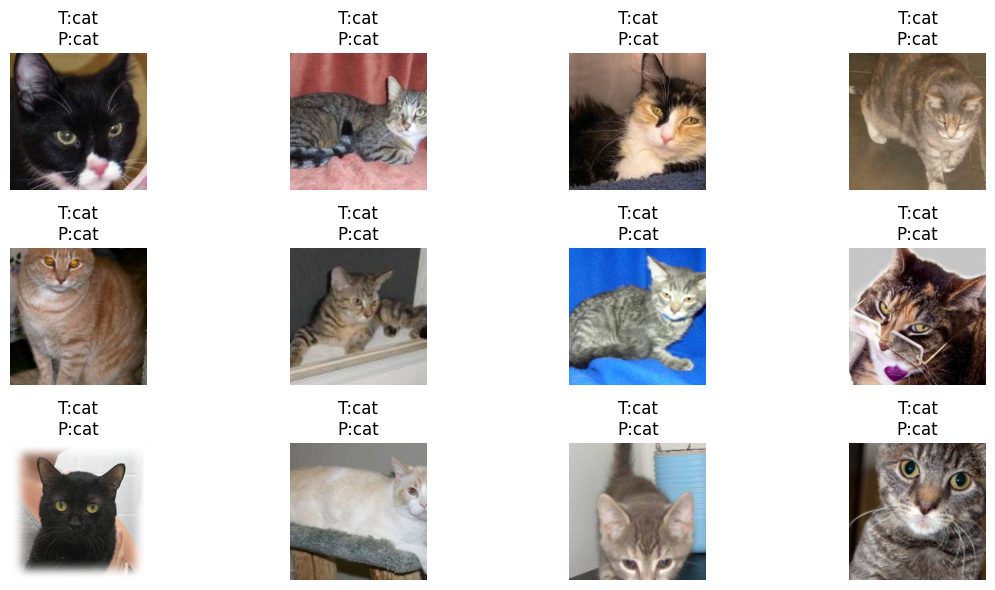

In [3]:
import matplotlib.pyplot as plt
import torch

final_acc = eval_acc()*100
print(f"Final validation accuracy: {final_acc:.2f}%")

model.eval()
x, y = next(iter(val_loader))
x_gpu = x.to(device)

with torch.no_grad():
    preds = model(x_gpu).argmax(1).cpu()

classes = train_ds.classes
mean = torch.tensor(IMAGENET_MEAN)
std  = torch.tensor(IMAGENET_STD)

plt.figure(figsize=(12,6))
for i in range(12):
    img = x[i].permute(1,2,0)
    img = (img*std + mean).clamp(0,1)
    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"T:{classes[y[i]]}\nP:{classes[preds[i]]}")
plt.tight_layout()
plt.show()